In [2]:
import pandas as pd
from datetime import date, timedelta

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'
random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"


greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [5]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [6]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [7]:
nuts2_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ']
nuts2_gdf.head()

,PER,geometry
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."


In [8]:
indexes = []

nuts2 = nuts2_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [9]:
nuts2_gdf.head()

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Έδεσσας,9043,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
3,Αλεξάνδρειας,9023,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
4,Αλμωπίας,9042,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."


<AxesSubplot:>

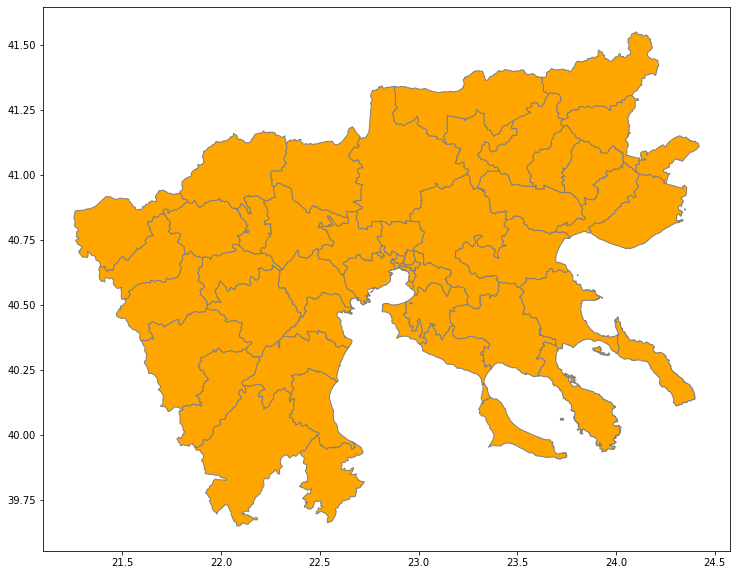

In [10]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [11]:
#check QGIS for wrong lau1 units

In [12]:
wrong_list = ['Φλώρινας' ,'Αμυνταίου', 'Εορδαίας', 'Κοζάνης', 'Σερβίων - Βελβεντού', 'Ελασσόνας', 'Τεμπών', 'Κάτω Νευροκοπίου',
 'Προσοτσάνης', 'Δοξάτου', 'Παγγαίου']

nuts2_gdf = nuts2_gdf[~nuts2_gdf['NAME'].isin(wrong_list)].copy()

In [13]:
nuts2_gdf.head(5)

,NAME,KWD_YPES,geometry
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Έδεσσας,9043,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
3,Αλεξάνδρειας,9023,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
4,Αλμωπίας,9042,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
5,Αμπελοκήπων - Μενεμένης,9026,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."


In [14]:
nuts2_gdf.drop(columns=['KWD_YPES'], inplace = True)
nuts2_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(nuts2_gdf, 'lau1')

In [15]:
nuts2_gdf.head(5)

,lau1,geometry
1,αθως,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,εδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
3,αλεξανδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
4,αλμωπιας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
5,αμπελοκηπων μενεμενης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."


<AxesSubplot:>

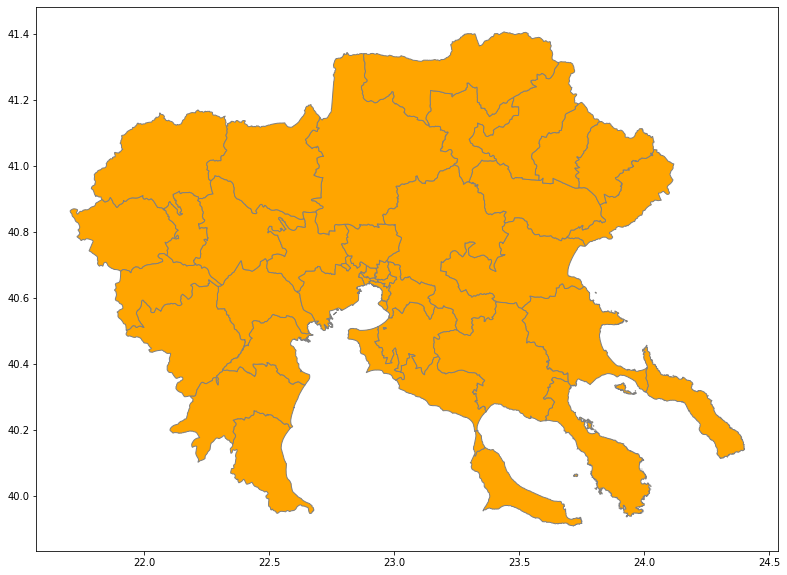

In [16]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [17]:
indexes = []

nuts2 = nuts2_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [18]:
nuts2_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,21,GR0009000400010100H,None,None,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,yes,17199.809546,"LINESTRING (21.73202 40.68216, 21.79637 40.773..."
1,224,GR001100040B230110N,ÓÔÑÕÌÙÍ Ð. 1,STRYMON R. 1,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,14069.595949,"LINESTRING (23.80988 40.90157, 23.80988 40.901..."
2,224,GR001100040B230110N,ÓÔÑÕÌÙÍ Ð. 1,STRYMON R. 1,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,14069.595949,"LINESTRING (23.80988 40.90157, 23.80988 40.901..."
3,224,GR001100040B230110N,ÓÔÑÕÌÙÍ Ð. 1,STRYMON R. 1,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,14069.595949,"LINESTRING (23.80988 40.90157, 23.80988 40.901..."
4,227,GR001100040B230320N,ÁÃÉÙÍ ÁÍÁÑÃÕÑÙÍ Ñ.,AGION ANARGYRON S.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,7703.516408,"LINESTRING (23.54881 41.12369, 23.54925 41.123..."


<AxesSubplot:>

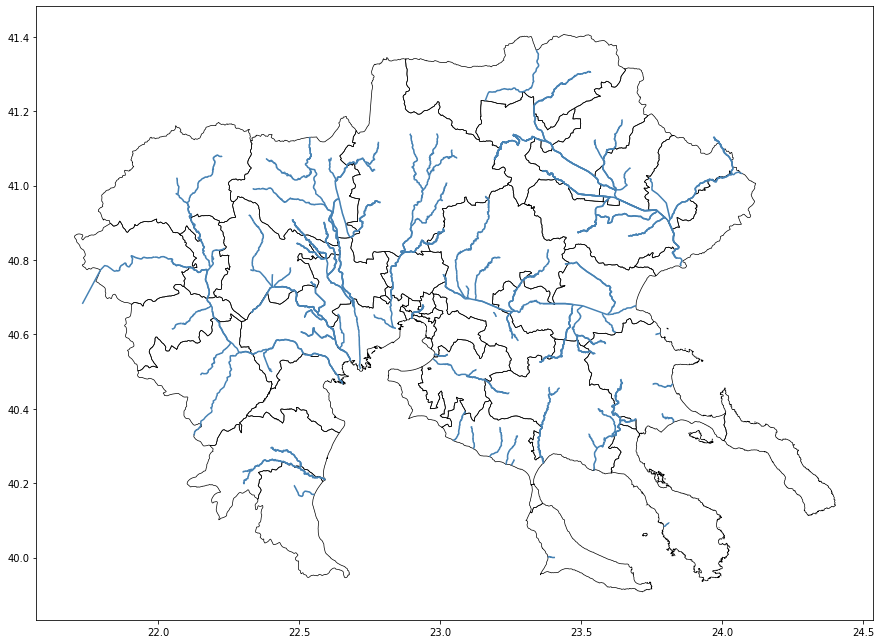

In [19]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [20]:
lau1_units = nuts2_gdf['lau1'].unique().tolist()

with open(f'data/{NUTS0}_SHP_{NUTS2}_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in lau1_units:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in {NUTS2} (from shapefile): {len(lau1_units)}")

Number of LAU1 Units in CMacedonia (from shapefile): 39


In [20]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [21]:
df_grid = create_grid(nuts2_rivers_gdf, nuts2_gdf, col_municipal='lau1', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

e:\Google Drive\NOA\MBD-Prediction\Greece\../Modules\preprocessing_utils.py:36: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.

In [22]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

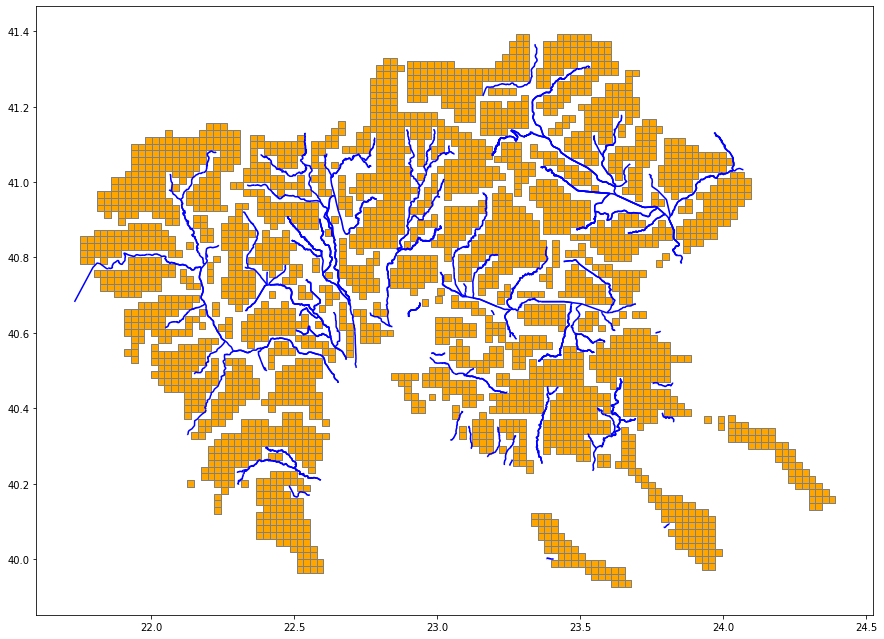

In [23]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [24]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 34


['αμπελοκηπων μενεμενης', 'θεσσαλονικης', 'καλαμαριας', 'κορδελιου ευοσμου', 'νεαπολης συκεων']


C:\Users\dimit\AppData\Local\Temp/ipykernel_12888/839959091.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lost_lau1["centroid"] = lost_lau1["geometry"].centroid
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


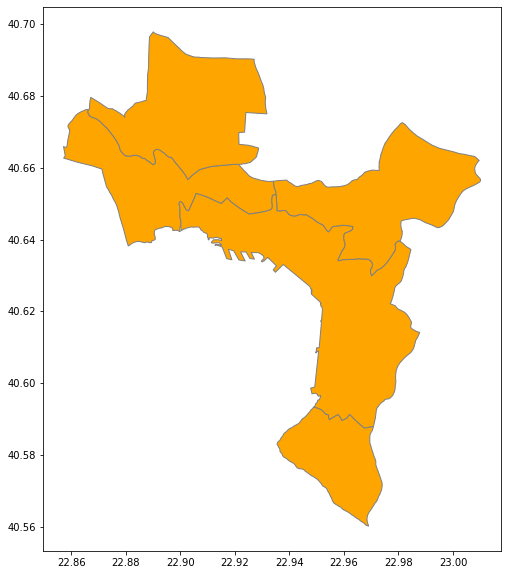

In [25]:
if (len(lau1_units) != len(grid_lau1)):
    delta = [item for item in lau1_units if item not in grid_lau1]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['lau1'] = lost_lau1['lau1']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [26]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [27]:
nuts2_grid

,geometry,lau1,x,y
0,"POLYGON ((24.03930 40.31053, 24.03930 40.32849...",αθως,24.02756,40.31951
1,"POLYGON ((24.03930 40.32849, 24.03930 40.34646...",αθως,24.02756,40.33748
2,"POLYGON ((24.03930 40.34646, 24.03930 40.36443...",αθως,24.02756,40.35544
3,"POLYGON ((24.03930 40.36443, 24.03930 40.38240...",αθως,24.02756,40.37341
4,"POLYGON ((24.06279 40.31053, 24.06279 40.32849...",αθως,24.05105,40.31951
...,...,...,...,...
2765,"POLYGON ((22.97626 40.78967, 22.97626 40.80764...",ωραιοκαστρου,22.96442,40.79866
2766,"POLYGON ((22.99996 40.73577, 22.99996 40.75374...",ωραιοκαστρου,22.98811,40.74476
2767,"POLYGON ((22.99996 40.75374, 22.99996 40.77171...",ωραιοκαστρου,22.98811,40.76272
2768,"POLYGON ((22.99996 40.77171, 22.99996 40.78967...",ωραιοκαστρου,22.98811,40.78069


In [28]:
if (len(lau1_units) != len(grid_lau1)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [29]:
nuts2_grid['nuts2'] = NUTS2_EL

In [30]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [31]:
nuts2_grid

,shape,lau1,x,y,nuts2
0,"POLYGON ((24.03930 40.31053, 24.03930 40.32849...",αθως,24.02756,40.31951,κεντρικης μακεδονιας
1,"POLYGON ((24.03930 40.32849, 24.03930 40.34646...",αθως,24.02756,40.33748,κεντρικης μακεδονιας
2,"POLYGON ((24.03930 40.34646, 24.03930 40.36443...",αθως,24.02756,40.35544,κεντρικης μακεδονιας
3,"POLYGON ((24.03930 40.36443, 24.03930 40.38240...",αθως,24.02756,40.37341,κεντρικης μακεδονιας
4,"POLYGON ((24.06279 40.31053, 24.06279 40.32849...",αθως,24.05105,40.31951,κεντρικης μακεδονιας
...,...,...,...,...,...
2770,"POLYGON ((22.87764 40.66601, 22.87775 40.66573...",αμπελοκηπων μενεμενης,22.89198,40.65603,κεντρικης μακεδονιας
2771,"POLYGON ((22.91314 40.65062, 22.91508 40.65002...",θεσσαλονικης,22.95369,40.62334,κεντρικης μακεδονιας
2772,"POLYGON ((22.97084 40.58797, 22.97046 40.58693...",καλαμαριας,22.95724,40.57876,κεντρικης μακεδονιας
2773,"POLYGON ((22.90533 40.69077, 22.90624 40.69074...",κορδελιου ευοσμου,22.90326,40.67609,κεντρικης μακεδονιας


In [32]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [33]:
nuts2_grid_points

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((24.03930 40.31053, 24.03930 40.32849...",αθως,24.02756,40.31951,κεντρικης μακεδονιας,POINT (24.02756 40.31951)
1,"POLYGON ((24.03930 40.32849, 24.03930 40.34646...",αθως,24.02756,40.33748,κεντρικης μακεδονιας,POINT (24.02756 40.33748)
2,"POLYGON ((24.03930 40.34646, 24.03930 40.36443...",αθως,24.02756,40.35544,κεντρικης μακεδονιας,POINT (24.02756 40.35544)
3,"POLYGON ((24.03930 40.36443, 24.03930 40.38240...",αθως,24.02756,40.37341,κεντρικης μακεδονιας,POINT (24.02756 40.37341)
4,"POLYGON ((24.06279 40.31053, 24.06279 40.32849...",αθως,24.05105,40.31951,κεντρικης μακεδονιας,POINT (24.05105 40.31951)
...,...,...,...,...,...,...
2770,"POLYGON ((22.87764 40.66601, 22.87775 40.66573...",αμπελοκηπων μενεμενης,22.89198,40.65603,κεντρικης μακεδονιας,POINT (22.89198 40.65603)
2771,"POLYGON ((22.91314 40.65062, 22.91508 40.65002...",θεσσαλονικης,22.95369,40.62334,κεντρικης μακεδονιας,POINT (22.95369 40.62334)
2772,"POLYGON ((22.97084 40.58797, 22.97046 40.58693...",καλαμαριας,22.95724,40.57876,κεντρικης μακεδονιας,POINT (22.95724 40.57876)
2773,"POLYGON ((22.90533 40.69077, 22.90624 40.69074...",κορδελιου ευοσμου,22.90326,40.67609,κεντρικης μακεδονιας,POINT (22.90326 40.67609)


<AxesSubplot:>

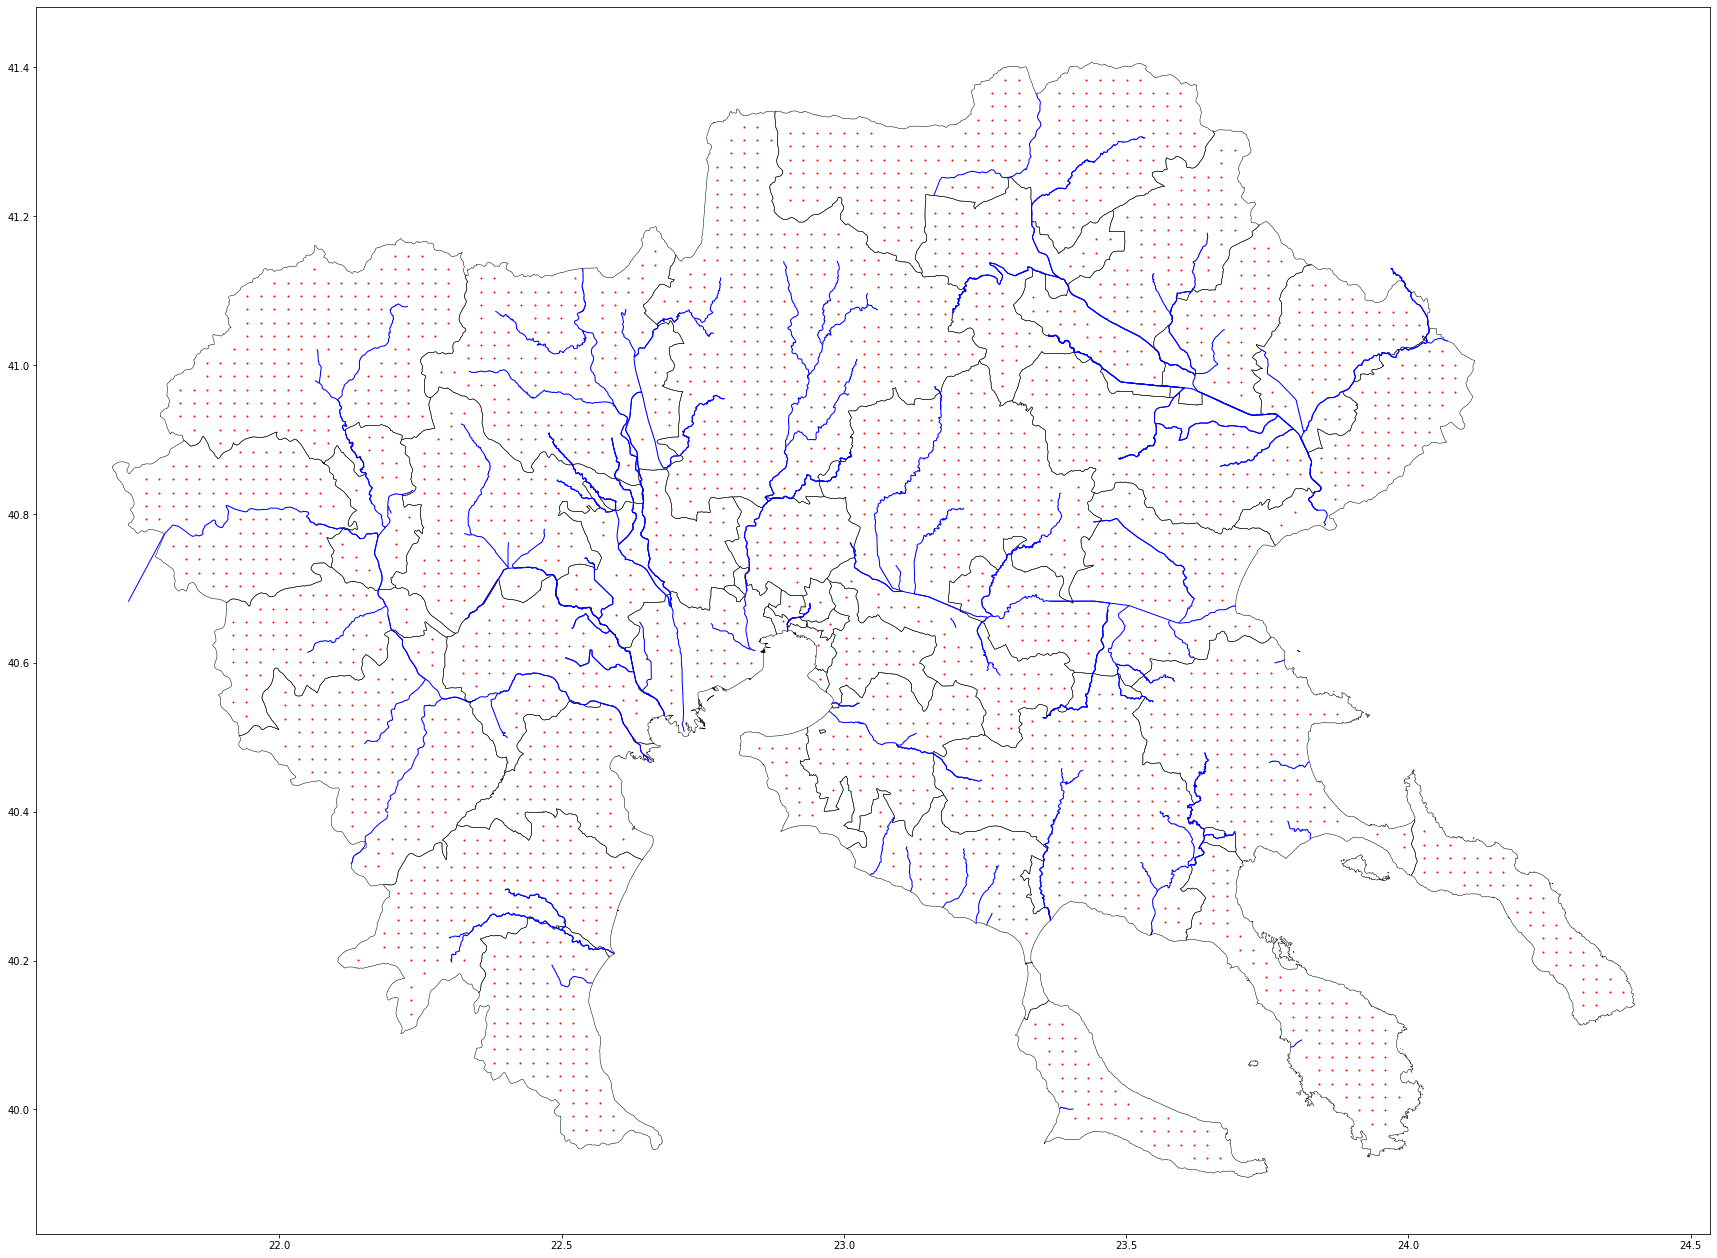

In [34]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [35]:
value_counts = nuts2_grid['lau1'].value_counts().sort_values()

In [36]:
arr = value_counts.values

In [37]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [38]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [39]:
value_counts_target

νεαπολης συκεων           1
παυλου μελα               1
αμπελοκηπων μενεμενης     1
κορδελιου ευοσμου         1
καλαμαριας                1
θεσσαλονικης              1
θερμαϊκου                 1
σκυδρας                   2
πυλαιας χορτιατη          2
δελτα                     2
ωραιοκαστρου              2
χαλκηδονος                3
νεας προποντιδας          3
εμμανουηλ παππα           3
θερμης                    3
κασσανδρας                3
πυδνας κολινδρου          4
αθως                      4
ναουσας                   4
αλεξανδρειας              4
νεας ζιχνης               4
ηρακλειας                 4
αμφιπολης                 4
σιθωνιας                  5
πελλας                    5
σερρων                    5
διου ολυμπου              6
βολβης                    6
βισαλτιας                 6
εδεσσας                   6
κατερινης                 7
παιονιας                  7
βεροιας                   7
αριστοτελη                8
πολυγυρου                 9
λαγκαδα             

In [40]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: θερμαϊκου || Value: 13 || Target Value: 1
Index: σκυδρας || Value: 18 || Target Value: 2
Index: πυλαιας χορτιατη || Value: 19 || Target Value: 2
Index: δελτα || Value: 26 || Target Value: 2
Index: ωραιοκαστρου || Value: 32 || Target Value: 2
Index: χαλκηδονος || Value: 39 || Target Value: 3
Index: νεας προποντιδας || Value: 39 || Target Value: 3
Index: εμμανουηλ παππα || Value: 42 || Target Value: 3
Index: θερμης || Value: 48 || Target Value: 3
Index: κασσανδρας || Value: 49 || Target Value: 3
Index: πυδνας κολινδρου || Value: 52 || Target Value: 4
Index: αθως || Value: 53 || Target Value: 4
Index: ναουσας || Value: 58 || Target Value: 4
Index: αλεξανδρειας || Value: 58 || Target Value: 4
Index: νεας ζιχνης || Value: 59 || Target Value: 4
Index: ηρακλειας || Value: 59 || Target Value: 4
Index: αμφιπολης || Value: 63 || Target Value: 4
Index: σιθωνιας || Value: 81 || Target Value: 5
Index: πελλας || Value: 85 || Target Value: 5
Index: σερρων || Value: 85 || Target Value: 5
Index:

In [41]:
to_remove = pd.Series(data=points, index=idx)

In [42]:
to_remove

θερμαϊκου            12
σκυδρας              16
πυλαιας χορτιατη     17
δελτα                24
ωραιοκαστρου         30
χαλκηδονος           36
νεας προποντιδας     36
εμμανουηλ παππα      39
θερμης               45
κασσανδρας           46
πυδνας κολινδρου     48
αθως                 49
ναουσας              54
αλεξανδρειας         54
νεας ζιχνης          55
ηρακλειας            55
αμφιπολης            59
σιθωνιας             76
πελλας               80
σερρων               80
διου ολυμπου         80
βολβης               86
βισαλτιας            93
εδεσσας              95
κατερινης           101
παιονιας            107
βεροιας             110
αριστοτελη          117
πολυγυρου           144
λαγκαδα             165
αλμωπιας            166
σιντικης            175
κιλκις              241
dtype: int64

In [43]:
indicies_to_remove = []

for municipality, points in to_remove.iteritems():
    indicies = nuts2_grid.loc[nuts2_grid['lau1'] ==  municipality].index.tolist()
    to_removed = random.sample(indicies, points)
    for item in to_removed:
        indicies_to_remove.append(item)

nuts2_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
nuts2_grid.reset_index(inplace = True, drop = True)

In [44]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

<AxesSubplot:>

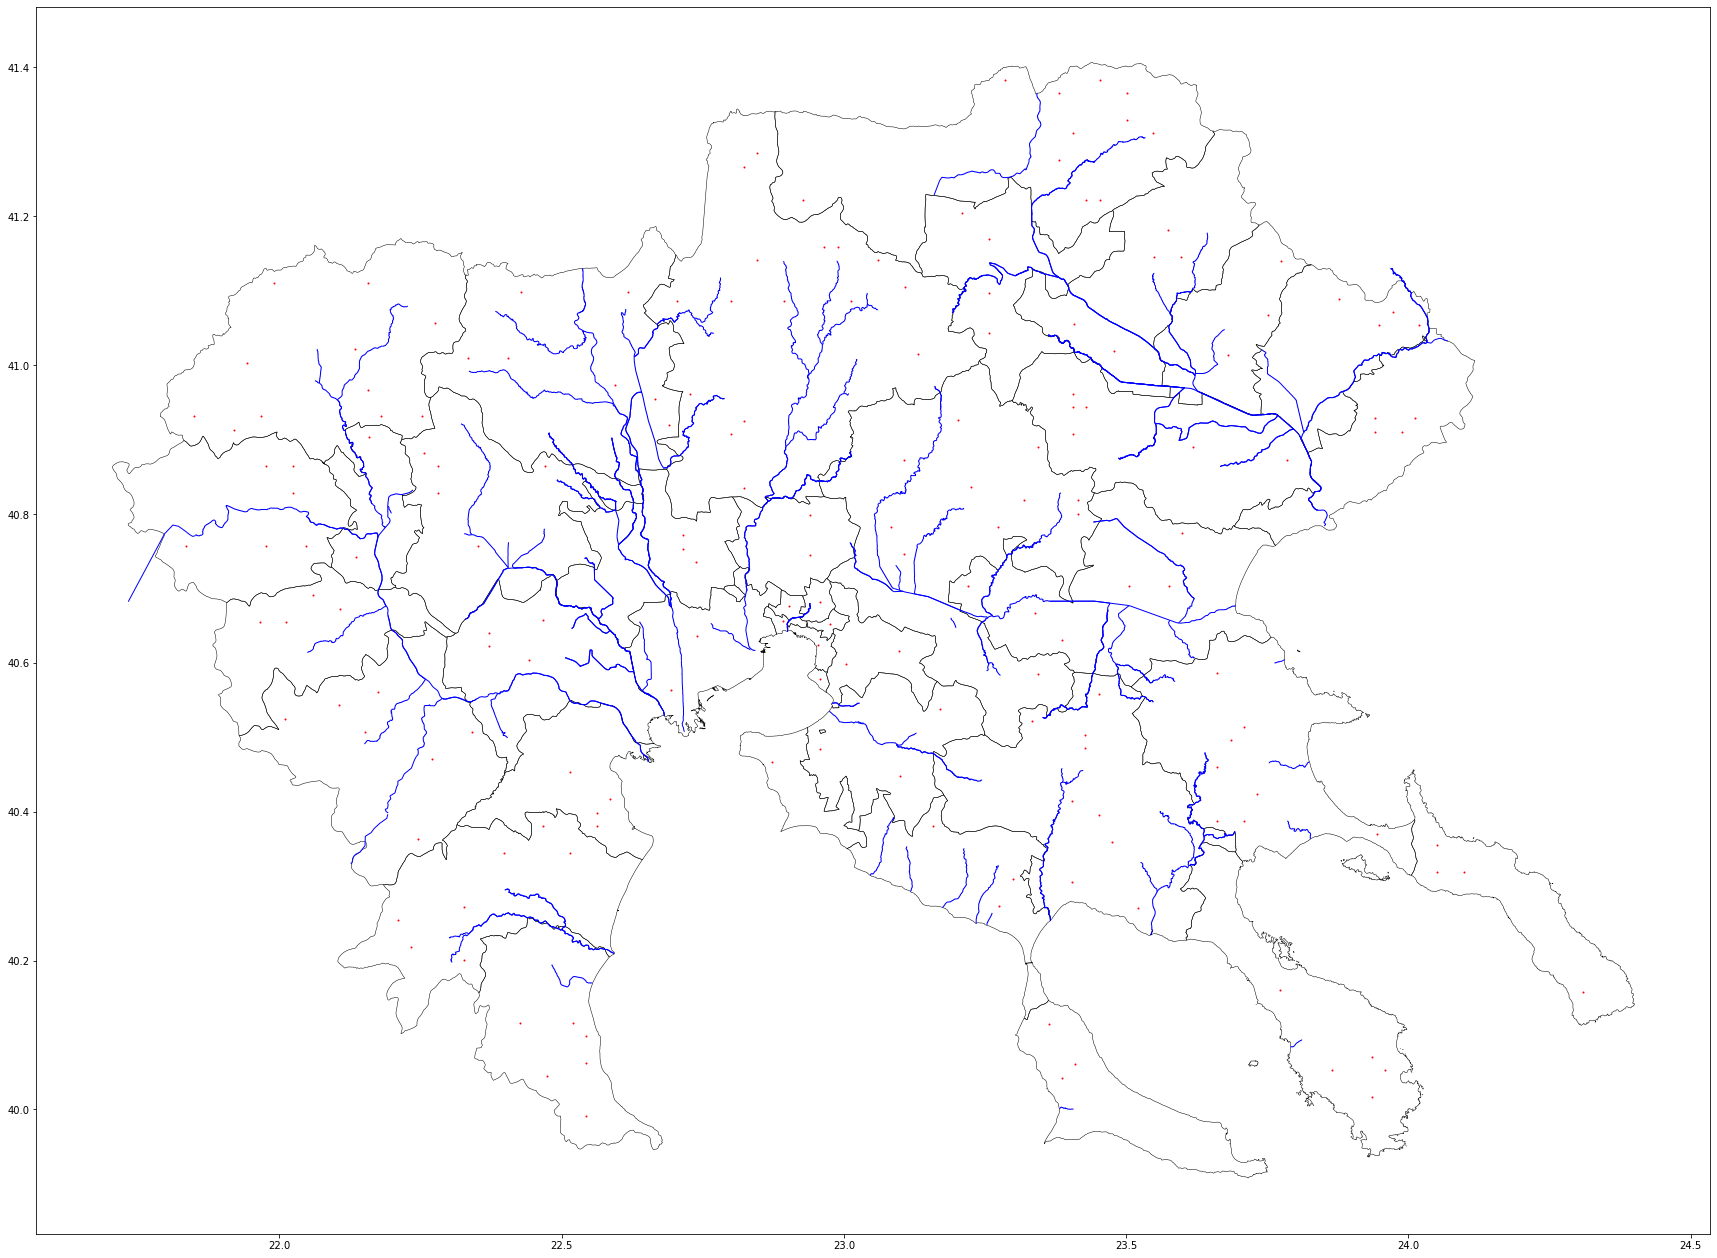

In [45]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [46]:
len(nuts2_grid['lau1'].unique())

39

In [47]:
nuts2_grid

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((24.06279 40.31053, 24.06279 40.32849...",αθως,24.05105,40.31951,κεντρικης μακεδονιας,POINT (24.05105 40.31951)
1,"POLYGON ((24.06279 40.34646, 24.06279 40.36443...",αθως,24.05105,40.35544,κεντρικης μακεδονιας,POINT (24.05105 40.35544)
2,"POLYGON ((24.10978 40.31053, 24.10978 40.32849...",αθως,24.09803,40.31951,κεντρικης μακεδονιας,POINT (24.09803 40.31951)
3,"POLYGON ((24.32121 40.14883, 24.32121 40.16679...",αθως,24.30947,40.15781,κεντρικης μακεδονιας,POINT (24.30947 40.15781)
4,"POLYGON ((21.84634 40.74801, 21.84634 40.76597...",εδεσσας,21.83449,40.75699,κεντρικης μακεδονιας,POINT (21.83449 40.75699)
...,...,...,...,...,...,...
179,"POLYGON ((22.87764 40.66601, 22.87775 40.66573...",αμπελοκηπων μενεμενης,22.89198,40.65603,κεντρικης μακεδονιας,POINT (22.89198 40.65603)
180,"POLYGON ((22.91314 40.65062, 22.91508 40.65002...",θεσσαλονικης,22.95369,40.62334,κεντρικης μακεδονιας,POINT (22.95369 40.62334)
181,"POLYGON ((22.97084 40.58797, 22.97046 40.58693...",καλαμαριας,22.95724,40.57876,κεντρικης μακεδονιας,POINT (22.95724 40.57876)
182,"POLYGON ((22.90533 40.69077, 22.90624 40.69074...",κορδελιου ευοσμου,22.90326,40.67609,κεντρικης μακεδονιας,POINT (22.90326 40.67609)


In [48]:
## start and end date is defined from available epidemiological file

In [49]:
start = start_dt = date(2010, 1, 1)
end = end_dt = date(2021, 12, 31)
delta = timedelta(days=1)

In [50]:
dates = []

while start_dt <= end_dt:
    dates.append(start_dt.isoformat())
    start_dt += delta

In [51]:
print('Dates between', start, 'and', end)
print(dates)

Dates between 2010-01-01 and 2021-12-31
['2010-01-01', '2010-01-02', '2010-01-03', '2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07', '2010-01-08', '2010-01-09', '2010-01-10', '2010-01-11', '2010-01-12', '2010-01-13', '2010-01-14', '2010-01-15', '2010-01-16', '2010-01-17', '2010-01-18', '2010-01-19', '2010-01-20', '2010-01-21', '2010-01-22', '2010-01-23', '2010-01-24', '2010-01-25', '2010-01-26', '2010-01-27', '2010-01-28', '2010-01-29', '2010-01-30', '2010-01-31', '2010-02-01', '2010-02-02', '2010-02-03', '2010-02-04', '2010-02-05', '2010-02-06', '2010-02-07', '2010-02-08', '2010-02-09', '2010-02-10', '2010-02-11', '2010-02-12', '2010-02-13', '2010-02-14', '2010-02-15', '2010-02-16', '2010-02-17', '2010-02-18', '2010-02-19', '2010-02-20', '2010-02-21', '2010-02-22', '2010-02-23', '2010-02-24', '2010-02-25', '2010-02-26', '2010-02-27', '2010-02-28', '2010-03-01', '2010-03-02', '2010-03-03', '2010-03-04', '2010-03-05', '2010-03-06', '2010-03-07', '2010-03-08', '2010-03-09', '2010-0

In [52]:
len(dates)

4383

In [53]:
nuts2_timeline = pd.DataFrame()

In [54]:
for index, row in nuts2_grid.iterrows():
    for date in dates:
        nuts2_timeline = nuts2_timeline.append({'lau1' : row['lau1'], 
                                                  'region' : row['nuts2'], 
                                                  'x' : row['x'],
                                                  'y' : row['y'],
                                                  'dt_placement': date}, 
                                                  ignore_index = True)

In [ ]:
nuts2_timeline

,lau1,region,x,y,dt_placement
0,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-01
1,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-02
2,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-03
3,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-04
4,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-05
...,...,...,...,...,...
806467,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-27
806468,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-28
806469,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-29
806470,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-30


In [ ]:
nuts2_timeline['dt_placement'] = pd.to_datetime(nuts2_timeline['dt_placement'])

In [ ]:
nuts2_timeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806472 entries, 0 to 806471
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   lau1          806472 non-null  object        
 1   region        806472 non-null  object        
 2   x             806472 non-null  float64       
 3   y             806472 non-null  float64       
 4   dt_placement  806472 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 30.8+ MB


In [ ]:
nuts2_timeline.to_csv(f'data/{NUTS0}_{NUTS2}_Spatiotemporal_Timeline_2010-2021.csv', index = False)

In [ ]:
nuts2_timeline

,lau1,region,x,y,dt_placement
0,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-01
1,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-02
2,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-03
3,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-04
4,αθως,κεντρικης μακεδονιας,24.05105,40.31951,2010-01-05
...,...,...,...,...,...
806467,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-27
806468,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-28
806469,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-29
806470,νεαπολης - συκεων,κεντρικης μακεδονιας,22.97547,40.65206,2021-12-30


In [ ]:
nuts2_timeline['dt_placement'].iloc[15].day

16

In [ ]:
nuts2_timeline_biweekly = nuts2_timeline.copy()
remove = []

for index, row in nuts2_timeline.iterrows():
    if row['dt_placement'].day == 1 or row['dt_placement'].day == 16:
        pass
    else:
        remove.append(index)


nuts2_timeline_biweekly.drop(index = remove, axis = 1, inplace = True)
nuts2_timeline_biweekly.reset_index(inplace = True, drop = True)

In [ ]:
nuts2_timeline_biweekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52992 entries, 0 to 52991
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   lau1          52992 non-null  object        
 1   region        52992 non-null  object        
 2   x             52992 non-null  float64       
 3   y             52992 non-null  float64       
 4   dt_placement  52992 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 2.0+ MB


In [ ]:
nuts2_timeline_biweekly.to_csv(f'data/{NUTS0}_{NUTS2}_Spatiotemporal_Timeline_Biweekly_2010-2021.csv', index = False)